Environment & Imports

In [6]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Add project root to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.eda_utils import calculate_risk_metrics, test_stationarity

Data Loading & Cleaning

In [7]:
# Load the data
df = pd.read_csv('../data/processed/market_data.csv', header=[0, 1], index_col=0, parse_dates=True)

# Select 'Close' prices (using our .xs method)
adj_close = df.xs('Close', level='Price', axis=1)

# Check for missing values
missing = adj_close.isnull().sum()
print("Missing values per asset:\n", missing)

# Handle missing values (if any)
adj_close = adj_close.ffill().bfill()
print("Cleaned data shape:", adj_close.shape)

Missing values per asset:
 Ticker
SPY     0
BND     0
TSLA    0
dtype: int64
Cleaned data shape: (2888, 3)


Visualizing Trends & Volatility

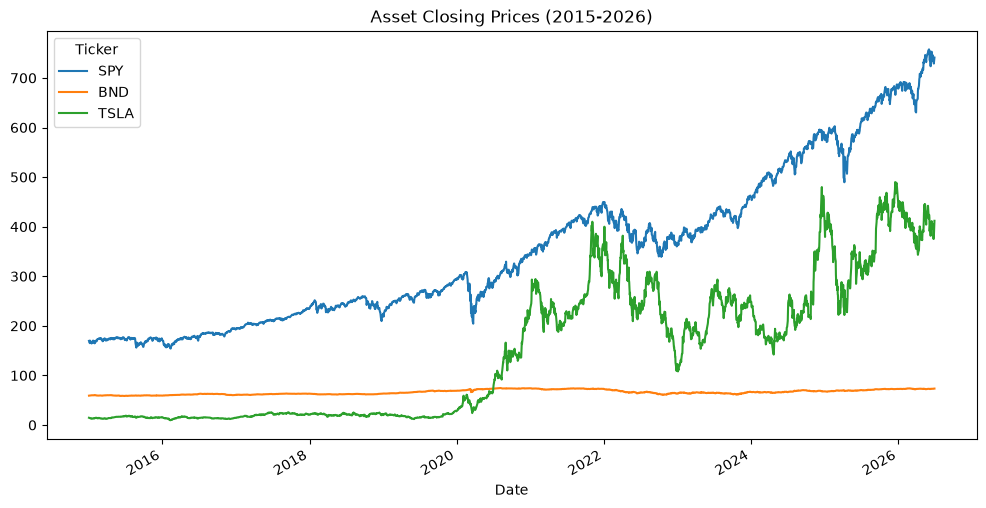

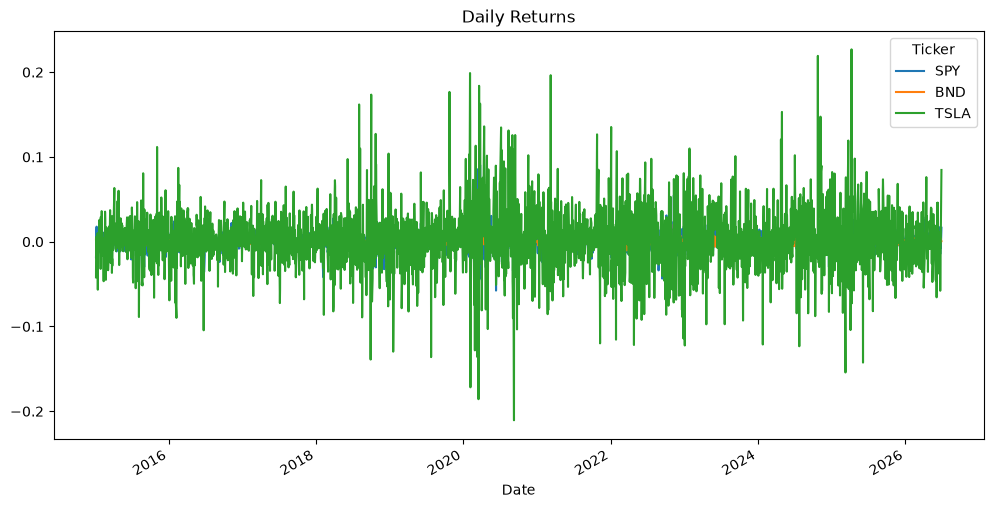

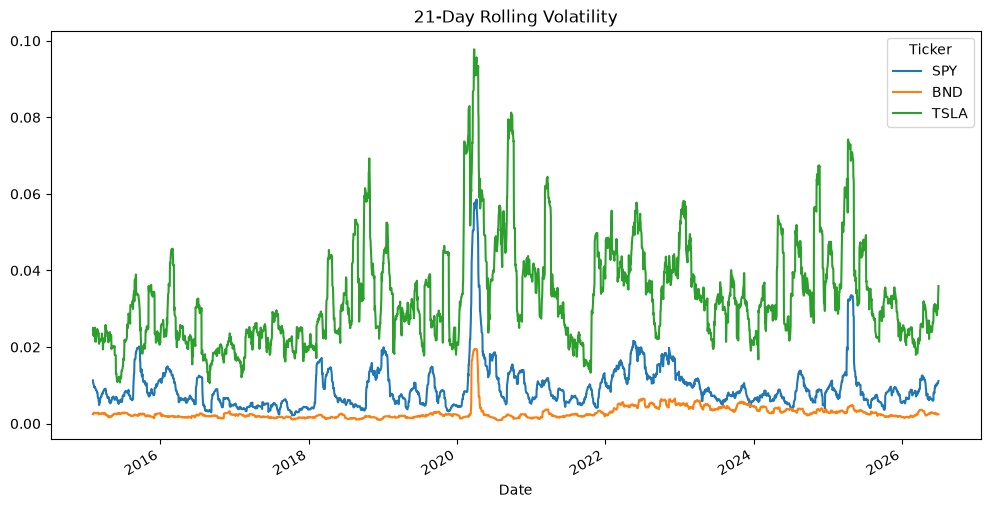

In [8]:
# 1. Price Trends
adj_close.plot(figsize=(12, 6), title="Asset Closing Prices (2015-2026)")
plt.show()

# 2. Daily Returns (to observe volatility spikes)
returns = adj_close.pct_change().dropna()
returns.plot(figsize=(12, 6), title="Daily Returns")
plt.show()

# 3. Rolling Volatility (21-day window)
rolling_vol = returns.rolling(window=21).std()
rolling_vol.plot(figsize=(12, 6), title="21-Day Rolling Volatility")
plt.show()

Stationarity Analysis

In [9]:
# Testing stationarity on Closing Prices
results = {ticker: test_stationarity(adj_close[ticker]) for ticker in adj_close.columns}
results_df = pd.DataFrame(results).T
print("ADF Test Results (Closing Prices):\n", results_df)

ADF Test Results (Closing Prices):
       ADF Statistic   p-value
SPY        1.308944  0.996659
BND       -1.047866  0.735409
TSLA      -1.069599  0.727042


Risk Metrics

In [10]:
# Calculate Sharpe Ratio and VaR
risk_metrics = calculate_risk_metrics(returns)
print("Portfolio Risk Metrics:\n", risk_metrics)

Portfolio Risk Metrics:
         Sharpe Ratio   95% VaR
Ticker                        
SPY         0.817462 -0.016650
BND         0.381196 -0.004757
TSLA        0.794437 -0.051664


Analysis

Stationarity (ADF Test): Your results (all $p > 0.05$) confirm that your raw price data is non-stationary.Implication: You cannot feed these raw prices directly into an ARIMA model. You must use differencing (transforming prices into returns) to stabilize the mean and variance.

Risk vs. Reward (Sharpe Ratio):SPY (0.817) offers the best risk-adjusted return among the three.
TSLA (0.794) is remarkably close to SPY in Sharpe ratio, but at a significantly higher cost in terms of risk.
Tail Risk (95% VaR):TSLA’s VaR of -0.0517 indicates that on a bad day, there is a 5% chance of losing more than 5.17% of the asset's value. 

Compare this to SPY (-1.67%) and BND (-0.48%), illustrating why TSLA requires careful position sizing within a portfolio.

Growth vs. Stability: The Asset Closing Prices chart shows TSLA’s explosive, volatile growth compared to the steady, low-slope trajectory of BND.

Volatility Clusters: The 21-Day Rolling Volatility chart clearly displays "volatility clustering"—periods of calm followed by massive spikes (most notably around 2020). This suggests that your model should account for heteroskedasticity (changing variance over time).